In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
import matplotlib.pyplot as plt
from collections import Counter
import random, time, os

In [3]:
# to reproduce in a consistent way
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

### Auto Augment is implemented here

In [5]:
train_transforms = T.Compose([
   AutoAugment(policy=AutoAugmentPolicy.CIFAR10),        # learned policy
    T.ToTensor(),
    T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

val_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

In [6]:
DATA_DIR = os.path.join(os.getcwd(), "data")
BATCH_SIZE = 64
NUM_WORKERS = 2

train = torchvision.datasets.CIFAR10(DATA_DIR, train=True,  transform=train_transforms, download = True)
val = torchvision.datasets.CIFAR10(DATA_DIR, train=False, transform=val_transforms, download = True)

In [7]:
def make_subset(dataset, fraction: float, seed: int = SEED):
    """Return subsets of dataset"""
    n = int(len(dataset) * fraction)
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=n, replace=False).tolist()
    return Subset(dataset, indices)

In [8]:

subset_10 = make_subset(train, fraction=0.10)
subset_25 = make_subset(train, fraction=0.25)
subset_50 = make_subset(train, fraction=0.50)

In [9]:
loaders = {
    "10%": DataLoader(subset_10,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "25%": DataLoader(subset_25,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "50%": DataLoader(subset_50,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "100%": DataLoader(train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
}
val_loader = DataLoader(val, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [10]:
class cnn(nn.Module):
    # in the requiremnents, it asked for a 4-layer
    def __init__(self, num_classes: int = 10, dropout: float = 0.5):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3,   32,  kernel_size=3, padding=1, bias=False),  
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                       
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32,  64,  kernel_size=3, padding=1, bias=False),  
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                       
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64,  128, kernel_size=3, padding=1, bias=False),  
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                       
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                                 
            nn.Dropout(p=dropout),
            nn.Linear(128 * 4 * 4, num_classes),                        
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x


In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_model(num_classes=10):
    model = cnn(num_classes=num_classes, dropout=0.5).to(DEVICE)

    
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # for p in model.parameters():
    #     if p.requires_grad:
    #         sum(p.)
            
    print(f"Trainable parameters: {total_params:,}")
    return model

In [12]:

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    
    model.train()
    
    running_loss = 0 # losses across batches
    correct = 0 # for accuracy calc
    total = 0 # total samples seen
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE) # for more speed
        
        optimizer.zero_grad() # we want clear grads from last batch not the last epoch
        
        with torch.amp.autocast('cuda'): # for more speed
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total += imgs.size(0)

        # print(running_loss)
        # print(correct)

        avg_loss = running_loss / total
        acc = correct * 100.0 / total
    
    return avg_loss, acc

In [13]:
@torch.no_grad() # we do not calculate grads when we evaluate
def evaluate(model, loader, criterion):
    
    model.eval()
    
    running_loss = 0 
    correct = 0 
    total = 0 
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
        running_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total += imgs.size(0)

        # print(running_loss)
        # print(correct)
    
        avg_loss = running_loss / total
        acc = correct * 100.0 / total
            
    return avg_loss, acc

In [14]:
def run_experiment(subset_name, num_epochs=30):
    print(f"  start: {subset_name} subset  ({num_epochs} epochs)")

    loader = loaders[subset_name]
    model = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    scaler = torch.amp.GradScaler('cuda')

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, loader, criterion, optimizer, scaler)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        
        train_losses.append(tr_loss)
        train_accs.append(tr_acc)
        val_losses.append(vl_loss)
        val_accs.append(vl_acc)

        # maybe we should add early stopping here
        print(f"epoch {epoch} | loss {tr_loss:.3f} | val acc {vl_acc:.1f}% | {time.time()-t0:.1f}s")


    best_val = max(val_accs)
    print(f"complete, best val: {best_val:.2f}%")

    ckpt_path = os.path.join(os.getcwd(), f"cnn4layer_{subset_name.replace('%', 'pct')}.pth")
    torch.save(model.state_dict(), ckpt_path)

    history = {"train_loss": train_losses, "train_acc": train_accs,
               "val_loss": val_losses, "val_acc": val_accs}
    
    return history, best_val

In [15]:
EPOCHS = 30          

results = {}
for subset in ["10%", "25%", "50%", "100%"]:         
    hist, best = run_experiment(subset, num_epochs=EPOCHS)
    results[subset] = {"history": hist, "best_val_acc": best}

  start: 10% subset  (30 epochs)
Trainable parameters: 113,962
epoch 1 | loss 2.203 | val acc 39.1% | 4.5s
epoch 2 | loss 1.892 | val acc 43.3% | 3.7s
epoch 3 | loss 1.760 | val acc 46.0% | 3.8s
epoch 4 | loss 1.664 | val acc 50.6% | 3.7s
epoch 5 | loss 1.588 | val acc 50.8% | 3.8s
epoch 6 | loss 1.520 | val acc 56.6% | 3.7s
epoch 7 | loss 1.489 | val acc 56.7% | 3.8s
epoch 8 | loss 1.433 | val acc 51.5% | 3.9s
epoch 9 | loss 1.376 | val acc 54.2% | 3.8s
epoch 10 | loss 1.389 | val acc 58.2% | 3.8s
epoch 11 | loss 1.309 | val acc 61.8% | 3.8s
epoch 12 | loss 1.298 | val acc 58.9% | 3.8s
epoch 13 | loss 1.267 | val acc 60.9% | 3.7s
epoch 14 | loss 1.265 | val acc 63.2% | 3.8s
epoch 15 | loss 1.225 | val acc 63.4% | 3.8s
epoch 16 | loss 1.166 | val acc 64.8% | 3.7s
epoch 17 | loss 1.177 | val acc 61.7% | 3.7s
epoch 18 | loss 1.174 | val acc 61.7% | 3.7s
epoch 19 | loss 1.146 | val acc 64.7% | 3.8s
epoch 20 | loss 1.118 | val acc 61.8% | 3.8s
epoch 21 | loss 1.097 | val acc 64.5% | 3.7s
e

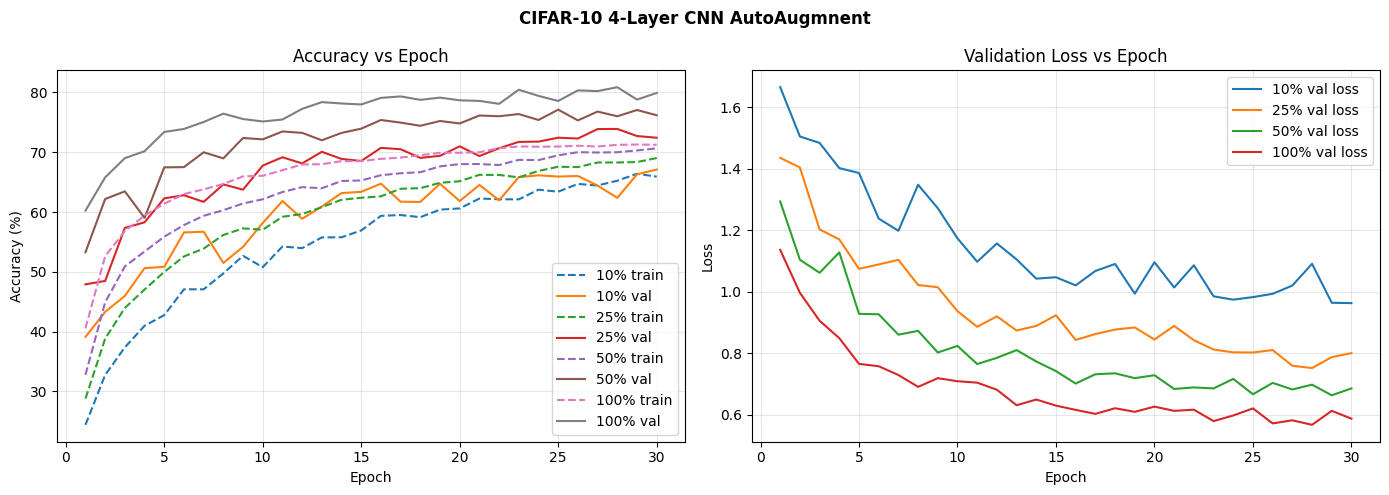

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, data in results.items():
    h = data["history"]
    epochs = range(1, len(h["val_acc"]) + 1)
    axes[0].plot(epochs, h["train_acc"], linestyle="--", label=f"{label} train")
    axes[0].plot(epochs, h["val_acc"],   linestyle="-",  label=f"{label} val")
    axes[1].plot(epochs, h["val_loss"],  linestyle="-",  label=f"{label} val loss")

axes[0].set_title("Accuracy vs Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation Loss vs Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("CIFAR-10 4-Layer CNN AutoAugmnent", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "training_curves.png"), dpi=150)
plt.show()

In [17]:
print(f"{'Subset':>8}  {'Best Val Acc':>13}  {'Train Samples':>14}")
for subset, data in results.items():
    n = len(loaders[subset].dataset)
    print(f"{subset:>8}  {data['best_val_acc']:>12.2f}%  {n:>14,}")

  Subset   Best Val Acc   Train Samples
     10%         67.11%           5,000
     25%         73.89%          12,500
     50%         77.12%          25,000
    100%         80.87%          50,000
